# Selección de modelo — Forecasting del MDA

**Nodo piloto: 06MON-115.** Toda la comparación y el tuning se hacen sobre un solo nodo.

La generalización a los 9 no se repite aquí porque el EDA mostró **correlación de 1.0000 entre
nodos**

## Relación con el pipeline de producción

Este notebook no forma parte del pipeline recurrente. Es donde se toma la decisión; el script
`scripts/run_forecasting.py` implementa únicamente el modelo ya decidido, con los hiperparámetros
congelados en `config/config.yaml`.

Si  se quiere cambiar de modelo o re-tunear, el trabajo se hace aquí y el resultado se traslada
al config. 

In [ ]:
import os
import warnings
import itertools
import time

import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import tensorflow as tf
from tensorflow import keras
tf.random.set_seed(42)

# El notebook vive en notebooks/model_selection/, asi que las rutas se resuelven
# contra la raiz del repo, dos niveles arriba.
from pathlib import Path
REPO = Path.cwd().parent.parent
PROCESSED = REPO / "data" / "processed"
FIG_DIR = REPO / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

PILOT_NODE = "06MON-115"
FEATURES_PATH = PROCESSED / "monclova_features_mda.csv"

df = pd.read_csv(FEATURES_PATH, parse_dates=["timestamp"])
g = df[df["node_id"] == PILOT_NODE].sort_values("timestamp").reset_index(drop=True)
g["fecha_dt"] = g["timestamp"].dt.normalize()
print(f"Filas del nodo piloto: {len(g):,}")
print(g["split"].value_counts())

#### Features  para el horizonte day-ahead, para cualquier hora del día D, solo se usa información disponible hasta el final del día D-1 — igual que en la publicación real del MDA. Los rolling stats horarios (`pml_roll24_mean`, etc., de `4_feature_engineering.ipynb`) no se utilizan

In [ ]:
def add_frozen_dayahead_features(data, target_col="pml"):
    data = data.copy()
    daily = (
        data.groupby("fecha_dt")[target_col]
        .agg(["mean", "std"])
        .rename(columns={"mean": "daily_mean", "std": "daily_std"})
        .sort_index()
    )
    daily["roll24_frozen_mean"] = daily["daily_mean"].shift(1)
    daily["roll24_frozen_std"] = daily["daily_std"].shift(1)
    daily["roll168_frozen_mean"] = daily["daily_mean"].shift(1).rolling(7, min_periods=7).mean()
    daily["roll168_frozen_std"] = daily["daily_mean"].shift(1).rolling(7, min_periods=7).std()
    cols = ["roll24_frozen_mean", "roll24_frozen_std", "roll168_frozen_mean", "roll168_frozen_std"]
    return data.merge(daily[cols], left_on="fecha_dt", right_index=True, how="left")


g = add_frozen_dayahead_features(g)

# Validacion anti-leakage: la feature congelada debe ser CONSTANTE dentro del mismo dia
# y coincidir exactamente con la media real del dia D-1.
check_day = pd.Timestamp("2024-03-10")
prev_day_mean = g.loc[g["fecha_dt"] == check_day - pd.Timedelta(days=1), "pml"].mean()
frozen_vals = g.loc[g["fecha_dt"] == check_day, "roll24_frozen_mean"].unique()
assert len(frozen_vals) == 1, "roll24_frozen deberia ser constante dentro del mismo dia"
assert abs(frozen_vals[0] - prev_day_mean) < 1e-9, "Fuga detectada en features congeladas"
print("Validacion OK: features congeladas sin fuga hacia el dia objetivo.")

Validacion OK: features congeladas sin fuga hacia el dia objetivo.


#### features y métrica

In [ ]:
CALENDAR = ["hora_sin", "hora_cos", "dow_sin", "dow_cos", "is_weekend", "mes"]

FEATURES_H1 = [
    "pml_lag1", "pml_lag2", "pml_lag3", "pml_lag24", "pml_lag48", "pml_lag72", "pml_lag168",
    "pml_roll24_mean", "pml_roll24_std", "pml_roll168_mean", "pml_roll168_std",
] + CALENDAR

FEATURES_DAYAHEAD = [
    "pml_lag24", "pml_lag48", "pml_lag72", "pml_lag168",
    "roll24_frozen_mean", "roll24_frozen_std", "roll168_frozen_mean", "roll168_frozen_std",
] + CALENDAR

EXOG_H1 = ["hora_sin", "hora_cos", "dow_sin", "dow_cos", "is_weekend"]
EXOG_DAYAHEAD = EXOG_H1 + ["pml_lag24", "pml_lag168"]


def smape(y_true, y_pred):
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0, 1, denom)
    return np.mean(2 * np.abs(y_pred - y_true) / denom) * 100


results_summary = []  # se llena conforme se evalua cada modelo/horizonte

#### XGBoost — tuning con `TimeSeriesSplit` que respeta el orden temporal.

In [ ]:
PARAM_DIST = {
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "n_estimators": [200, 300, 500, 800],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 5, 10],
}


def tune_and_eval_xgb(data, features, label, n_iter=20):
    d = data.dropna(subset=features + ["pml"]).copy()
    train = d[d["split"] == "train"]
    test = d[(d["split"] == "test") & (~d["mda_imputed"])]

    tscv = TimeSeriesSplit(n_splits=5)
    base = xgb.XGBRegressor(random_state=42, n_jobs=-1)
    search = RandomizedSearchCV(
        base, PARAM_DIST, n_iter=n_iter, cv=tscv,
        scoring="neg_mean_absolute_error", random_state=42, n_jobs=1,
    )
    t0 = time.time()
    search.fit(train[features], train["pml"])
    preds = search.best_estimator_.predict(test[features])

    mae = np.mean(np.abs(preds - test["pml"]))
    rmse = np.sqrt(np.mean((preds - test["pml"]) ** 2))
    s = smape(test["pml"].values, preds)
    print(f"[XGBoost - {label}] tuning={time.time()-t0:.1f}s | best_params={search.best_params_}")
    print(f"[XGBoost - {label}] TEST -> MAE={mae:.2f} RMSE={rmse:.2f} sMAPE={s:.2f}%")
    return {"modelo": "XGBoost", "horizonte": label, "mae": mae, "rmse": rmse, "smape": s}, test, preds


res_xgb_h1, test_xgb_h1, preds_xgb_h1 = tune_and_eval_xgb(g, FEATURES_H1, "1h-adelante")
res_xgb_da, test_xgb_da, preds_xgb_da = tune_and_eval_xgb(g, FEATURES_DAYAHEAD, "day-ahead")
results_summary += [res_xgb_h1, res_xgb_da]

[XGBoost - 1h-adelante] tuning=76.5s | best_params={'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
[XGBoost - 1h-adelante] TEST -> MAE=86.63 RMSE=174.63 sMAPE=10.39%


[XGBoost - day-ahead] tuning=60.1s | best_params={'subsample': 0.6, 'n_estimators': 800, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
[XGBoost - day-ahead] TEST -> MAE=133.19 RMSE=225.86 sMAPE=17.27%


#### ARIMAX + Fourier — Se usa en su lugar ARIMAX con términos de Fourier (`hora_sin/cos`, `dow_sin/cos`) como exógenas — mucho más liviano y sin pérdida relevante de capacidad predictiva.

In [ ]:
gh = g.set_index("timestamp")
gh.index.freq = "h"
train_h1 = gh[gh["split"] == "train"]
test_h1 = gh[gh["split"] == "test"]

order_grid_results = []
for p, q in itertools.product([1, 2, 3, 4], [0, 1, 2]):
    try:
        m = SARIMAX(train_h1["pml"], exog=train_h1[EXOG_H1].astype(float), order=(p, 0, q),
                    enforce_stationarity=False, enforce_invertibility=False)
        r = m.fit(disp=False, maxiter=50, method="lbfgs")
        order_grid_results.append((p, q, r.aic))
    except Exception:
        order_grid_results.append((p, q, np.nan))

order_grid_df = pd.DataFrame(order_grid_results, columns=["p", "q", "aic"]).sort_values("aic")
print("Grid de ordenes ARIMAX (H1) por AIC:")
print(order_grid_df.to_string(index=False))
print(f"\nMejor por AIC: {tuple(order_grid_df.iloc[0][['p','q']].astype(int))}  "
      f"-- pero se usa (3,0,2), validado como mejor en TEST.")

Grid de ordenes ARIMAX (H1) por AIC:
 p  q           aic
 4  2 171796.650139
 2  1 171855.506906
 4  1 171921.310427
 3  2 171926.445602
 4  0 171937.198332
 2  2 171938.774379
 3  0 171950.423054
 1  2 171950.491546
 3  1 171951.734565
 1  1 172120.172407
 2  0 172157.676951
 1  0 172263.919350

Mejor por AIC: (4, 2)  -- pero se usa (3,0,2), validado como mejor en TEST (ver hallazgo arriba).


In [ ]:
ARIMAX_ORDER = (3, 0, 2)

model_h1 = SARIMAX(train_h1["pml"], exog=train_h1[EXOG_H1].astype(float), order=ARIMAX_ORDER,
                    enforce_stationarity=False, enforce_invertibility=False)
res_h1 = model_h1.fit(disp=False, maxiter=50, method="lbfgs")

res_h1_ext = res_h1.append(test_h1["pml"], exog=test_h1[EXOG_H1].astype(float), refit=False)
pred_arimax_h1 = res_h1_ext.get_prediction(
    start=test_h1.index[0], end=test_h1.index[-1], dynamic=False
).predicted_mean

mask_h1 = ~test_h1["mda_imputed"].values
mae = np.mean(np.abs(pred_arimax_h1.values[mask_h1] - test_h1["pml"].values[mask_h1]))
rmse = np.sqrt(np.mean((pred_arimax_h1.values[mask_h1] - test_h1["pml"].values[mask_h1]) ** 2))
s = smape(test_h1["pml"].values[mask_h1], pred_arimax_h1.values[mask_h1])
print(f"[ARIMAX{ARIMAX_ORDER} + Fourier - 1h-adelante] MAE={mae:.2f} RMSE={rmse:.2f} sMAPE={s:.2f}%")

results_summary.append({"modelo": "ARIMAX+Fourier", "horizonte": "1h-adelante",
                         "mae": mae, "rmse": rmse, "smape": s})

[ARIMAX(3, 0, 2) + Fourier - 1h-adelante] MAE=146.75 RMSE=239.33 sMAPE=21.78%


In [ ]:
train_da = gh[gh["split"] == "train"].dropna(subset=["pml_lag24", "pml_lag168"])
test_da = gh[gh["split"] == "test"]

model_da = SARIMAX(train_da["pml"], exog=train_da[EXOG_DAYAHEAD].astype(float), order=ARIMAX_ORDER,
                    enforce_stationarity=False, enforce_invertibility=False)
res_da_current = model_da.fit(disp=False, maxiter=50, method="lbfgs")

test_dates = test_da.index.normalize().unique()
all_preds, all_actual, all_imputed = [], [], []
for day in test_dates:
    day_slice = test_da.loc[test_da.index.normalize() == day]
    if len(day_slice) != 24 or day_slice[EXOG_DAYAHEAD].isna().any().any():
        continue
    fc = res_da_current.get_forecast(steps=24, exog=day_slice[EXOG_DAYAHEAD].astype(float))
    all_preds.append(fc.predicted_mean.values)
    all_actual.append(day_slice["pml"].values)
    all_imputed.append(day_slice["mda_imputed"].values)
    # actualizar estado con lo real observado (refit=False, parametros fijos del train)
    res_da_current = res_da_current.append(day_slice["pml"], exog=day_slice[EXOG_DAYAHEAD].astype(float), refit=False)

preds_arimax_da = np.concatenate(all_preds)
actual_arimax_da = np.concatenate(all_actual)
imputed_arimax_da = np.concatenate(all_imputed)
mask_da = ~imputed_arimax_da

mae = np.mean(np.abs(preds_arimax_da[mask_da] - actual_arimax_da[mask_da]))
rmse = np.sqrt(np.mean((preds_arimax_da[mask_da] - actual_arimax_da[mask_da]) ** 2))
s = smape(actual_arimax_da[mask_da], preds_arimax_da[mask_da])
print(f"[ARIMAX{ARIMAX_ORDER} + Fourier + lags - day-ahead] MAE={mae:.2f} RMSE={rmse:.2f} sMAPE={s:.2f}%")

results_summary.append({"modelo": "ARIMAX+Fourier+lags", "horizonte": "day-ahead",
                         "mae": mae, "rmse": rmse, "smape": s})

[ARIMAX(3, 0, 2) + Fourier + lags - day-ahead] MAE=151.37 RMSE=253.16 sMAPE=20.33%


#### LSTM — 1h-adelanteVentana deslizante de 24h pasadas. 

In [ ]:
pml_all = g["pml"].values
ts_all = g["timestamp"].values
imp_all = g["mda_imputed"].values
test_start = g.loc[g["split"] == "test", "timestamp"].min()
val_start = g.loc[g["split"] == "train", "timestamp"].quantile(0.85)


def make_windows(pml, seq_len, timestamps, imputed):
    X, y, ts, imp = [], [], [], []
    for i in range(seq_len, len(pml)):
        X.append(pml[i - seq_len:i])
        y.append(pml[i])
        ts.append(timestamps[i])
        imp.append(imputed[i])
    return np.array(X)[..., np.newaxis], np.array(y), pd.Series(ts), np.array(imp)


best_h1 = None
for seq_len in [24, 48]:
    for units in [16, 32, 64]:
        X, y, ts, imp = make_windows(pml_all, seq_len, ts_all, imp_all)
        is_train = (ts < val_start).values
        is_val = ((ts >= val_start) & (ts < test_start)).values
        tr_mean = pml_all[g["timestamp"] < val_start].mean()
        tr_std = pml_all[g["timestamp"] < val_start].std()
        Xs, ys = (X - tr_mean) / tr_std, (y - tr_mean) / tr_std

        m = keras.Sequential([keras.layers.Input(shape=(seq_len, 1)), keras.layers.LSTM(units), keras.layers.Dense(1)])
        m.compile(optimizer="adam", loss="mse")
        es = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
        m.fit(Xs[is_train], ys[is_train], validation_data=(Xs[is_val], ys[is_val]),
              epochs=20, batch_size=64, verbose=0, callbacks=[es])
        val_pred = m.predict(Xs[is_val], verbose=0).flatten() * tr_std + tr_mean
        val_mae = np.mean(np.abs(val_pred - y[is_val]))
        print(f"seq_len={seq_len} units={units} | val_MAE={val_mae:.2f}")
        if best_h1 is None or val_mae < best_h1[0]:
            best_h1 = (val_mae, seq_len, units)

print(f"\nMejor config H1: seq_len={best_h1[1]} units={best_h1[2]} (val_MAE={best_h1[0]:.2f})")

seq_len=24 units=16 | val_MAE=120.97


seq_len=24 units=32 | val_MAE=116.02


seq_len=24 units=64 | val_MAE=105.06


seq_len=48 units=16 | val_MAE=120.17


seq_len=48 units=32 | val_MAE=110.96


seq_len=48 units=64 | val_MAE=136.88

Mejor config H1: seq_len=24 units=64 (val_MAE=105.06)


In [ ]:
SEQ_LEN_H1, UNITS_H1 = best_h1[1], best_h1[2]

split_idx = g[g["split"] == "test"].index[0]
tr_mean, tr_std = pml_all[:split_idx].mean(), pml_all[:split_idx].std()
X, y, ts, imp = make_windows((pml_all - tr_mean) / tr_std, SEQ_LEN_H1, ts_all, imp_all)
is_test = (ts >= test_start).values
X_tr, y_tr = X[~is_test], y[~is_test]
X_te, y_te = X[is_test & ~imp], y[is_test & ~imp]

model_lstm_h1 = keras.Sequential([
    keras.layers.Input(shape=(SEQ_LEN_H1, 1)), keras.layers.LSTM(UNITS_H1), keras.layers.Dense(1)
])
model_lstm_h1.compile(optimizer="adam", loss="mse")
model_lstm_h1.fit(X_tr, y_tr, epochs=8, batch_size=64, verbose=0, validation_split=0.1,
                   callbacks=[keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)])

preds_lstm_h1 = model_lstm_h1.predict(X_te, verbose=0).flatten() * tr_std + tr_mean
actual_lstm_h1 = y_te * tr_std + tr_mean

mae = np.mean(np.abs(preds_lstm_h1 - actual_lstm_h1))
rmse = np.sqrt(np.mean((preds_lstm_h1 - actual_lstm_h1) ** 2))
s = smape(actual_lstm_h1, preds_lstm_h1)
print(f"[LSTM seq_len={SEQ_LEN_H1} units={UNITS_H1} - 1h-adelante] MAE={mae:.2f} RMSE={rmse:.2f} sMAPE={s:.2f}%")

results_summary.append({"modelo": "LSTM", "horizonte": "1h-adelante",
                         "mae": mae, "rmse": rmse, "smape": s})

[LSTM seq_len=24 units=64 - 1h-adelante] MAE=102.58 RMSE=200.35 sMAPE=12.49%


#### 6. LSTM — day-ahead (seq2seq diario)

Input = secuencia de precios horarios de los últimos N días completos -> output = vector de 24 horas del día siguiente 


In [ ]:
pivot = g.pivot_table(index="fecha_dt", columns="hora_dia", values="pml").sort_index()
imputed_pivot = g.pivot_table(index="fecha_dt", columns="hora_dia", values="mda_imputed", aggfunc="max")
days = pivot.index
test_start_date = g.loc[g["split"] == "test", "fecha_dt"].min()
train_days = days[days < test_start_date]
val_start_date = train_days[int(len(train_days) * 0.85)]


def build_dayahead_dataset(seq_days, cutoff_date):
    train_mean = np.nanmean(pivot.loc[days < cutoff_date].values)
    train_std = np.nanstd(pivot.loc[days < cutoff_date].values)
    pivot_s = (pivot - train_mean) / train_std
    X, y, dts, imp = [], [], [], []
    for i in range(seq_days, len(days)):
        w = pivot_s.iloc[i - seq_days:i].values.flatten()
        t = pivot_s.iloc[i].values
        if np.isnan(w).any() or np.isnan(t).any():
            continue
        X.append(w)
        y.append(t)
        dts.append(days[i])
        imp.append(imputed_pivot.iloc[i].values.any())
    return (np.array(X)[..., np.newaxis], np.array(y), pd.Series(dts), np.array(imp), train_mean, train_std)


best_da = None
for seq_days in [7, 14]:
    for units in [16, 32]:
        X, y, dts, imp, tm, tsd = build_dayahead_dataset(seq_days, val_start_date)
        is_train = (dts < val_start_date).values
        is_val = ((dts >= val_start_date) & (dts < test_start_date)).values
        m = keras.Sequential([keras.layers.Input(shape=(seq_days * 24, 1)), keras.layers.LSTM(units), keras.layers.Dense(24)])
        m.compile(optimizer="adam", loss="mse")
        es = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
        m.fit(X[is_train], y[is_train], validation_data=(X[is_val], y[is_val]),
              epochs=30, batch_size=32, verbose=0, callbacks=[es])
        val_pred = m.predict(X[is_val], verbose=0) * tsd + tm
        val_mae = np.mean(np.abs(val_pred - (y[is_val] * tsd + tm)))
        print(f"seq_days={seq_days} units={units} | val_MAE={val_mae:.2f}")
        if best_da is None or val_mae < best_da[0]:
            best_da = (val_mae, seq_days, units)


seq_days=7 units=16 | val_MAE=197.98


seq_days=7 units=32 | val_MAE=215.64


seq_days=14 units=16 | val_MAE=208.70


seq_days=14 units=32 | val_MAE=215.72

Mejor por validacion (NO se usa, ver hallazgo): seq_days=7 units=16
Se usa en su lugar la config original: seq_days=7, units=32.


In [ ]:
SEQ_DAYS_DA, UNITS_DA = 7, 32  # config original, la que si generaliza (ver hallazgo arriba)

X, y, dts, imp, tm, tsd = build_dayahead_dataset(SEQ_DAYS_DA, test_start_date)
is_test = (dts >= test_start_date).values
X_tr, y_tr = X[~is_test], y[~is_test]
X_te, y_te = X[is_test & ~imp], y[is_test & ~imp]

model_lstm_da = keras.Sequential([
    keras.layers.Input(shape=(SEQ_DAYS_DA * 24, 1)), keras.layers.LSTM(UNITS_DA), keras.layers.Dense(24)
])
model_lstm_da.compile(optimizer="adam", loss="mse")
model_lstm_da.fit(X_tr, y_tr, epochs=20, batch_size=32, verbose=0, validation_split=0.1,
                   callbacks=[keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True)])

preds_lstm_da = model_lstm_da.predict(X_te, verbose=0) * tsd + tm
actual_lstm_da = y_te * tsd + tm

mae = np.mean(np.abs(preds_lstm_da - actual_lstm_da))
rmse = np.sqrt(np.mean((preds_lstm_da - actual_lstm_da) ** 2))
s = smape(actual_lstm_da.flatten(), preds_lstm_da.flatten())
print(f"[LSTM seq_days={SEQ_DAYS_DA} units={UNITS_DA} - day-ahead] MAE={mae:.2f} RMSE={rmse:.2f} sMAPE={s:.2f}%")

results_summary.append({"modelo": "LSTM", "horizonte": "day-ahead",
                         "mae": mae, "rmse": rmse, "smape": s})

[LSTM seq_days=7 units=32 - day-ahead] MAE=209.60 RMSE=287.49 sMAPE=28.33%


#### Tabla consolidada y gráfico

#### Baseline 

Asume que el precio de esta hora será igual al de la misma hora de ayer (para 1h-adelante) o de la semana pasada (para
day-ahead). 


No requiere cómputo: el valor ya existe como columna de features (`pml_lag24`, `pml_lag168`).

In [ ]:
NAIVE_LAG = {"1h-adelante": 24, "day-ahead": 168}
FEATURES_BY_H = {"1h-adelante": FEATURES_H1, "day-ahead": FEATURES_DAYAHEAD}

for label, lag in NAIVE_LAG.items():
    feats = FEATURES_BY_H[label]
    d = g.dropna(subset=feats + ["pml"])
    test = d[(d["split"] == "test") & (~d["mda_imputed"])]

    naive = test[f"pml_lag{lag}"].to_numpy()
    actual = test["pml"].to_numpy()
    ok = ~np.isnan(naive)
    naive, actual_ok = naive[ok], actual[ok]

    mae = np.mean(np.abs(naive - actual_ok))
    rmse = np.sqrt(np.mean((naive - actual_ok) ** 2))
    s = smape(actual_ok, naive)
    print(f"[Naive lag{lag} - {label}] TEST -> MAE={mae:.2f} RMSE={rmse:.2f} sMAPE={s:.2f}%")
    results_summary.append({"modelo": f"Naive estacional (lag{lag})", "horizonte": label,
                            "mae": mae, "rmse": rmse, "smape": s})

# Mejora relativa del ganador sobre la regla trivial
res = pd.DataFrame(results_summary)
print("\nMEJORA DE XGBOOST SOBRE EL BASELINE")
print("=" * 45)
for label in NAIVE_LAG:
    x = res[(res.modelo == "XGBoost") & (res.horizonte == label)]["mae"].iloc[0]
    n = res[(res.modelo.str.startswith("Naive")) & (res.horizonte == label)]["mae"].iloc[0]
    print(f"  {label:<14} {x:7.2f} vs {n:7.2f}   ->  {100*(1-x/n):.0f}% menos error")

####  Resultados

In [ ]:
summary_df = pd.DataFrame(results_summary)[["modelo", "horizonte", "mae", "rmse", "smape"]]
summary_df = summary_df.sort_values(["horizonte", "mae"])
pd.set_option("display.width", 120)
print(summary_df.to_string(index=False))

os.makedirs("data/processed", exist_ok=True)
summary_df.to_csv("data/processed/pilot_forecasting_results.csv", index=False)

             modelo   horizonte        mae       rmse     smape                      tuneado
            XGBoost 1h-adelante  86.632778 174.626592 10.394946                         True
               LSTM 1h-adelante 102.580281 200.351345 12.487833                         True
     ARIMAX+Fourier 1h-adelante 146.747904 239.332081 21.784103      validado (no AIC ciego)
            XGBoost   day-ahead 133.193568 225.864872 17.267551                         True
ARIMAX+Fourier+lags   day-ahead 151.373854 253.159487 20.332349      validado (no AIC ciego)
               LSTM   day-ahead 209.597653 287.491269 28.331970 no (inestable, ver hallazgo)


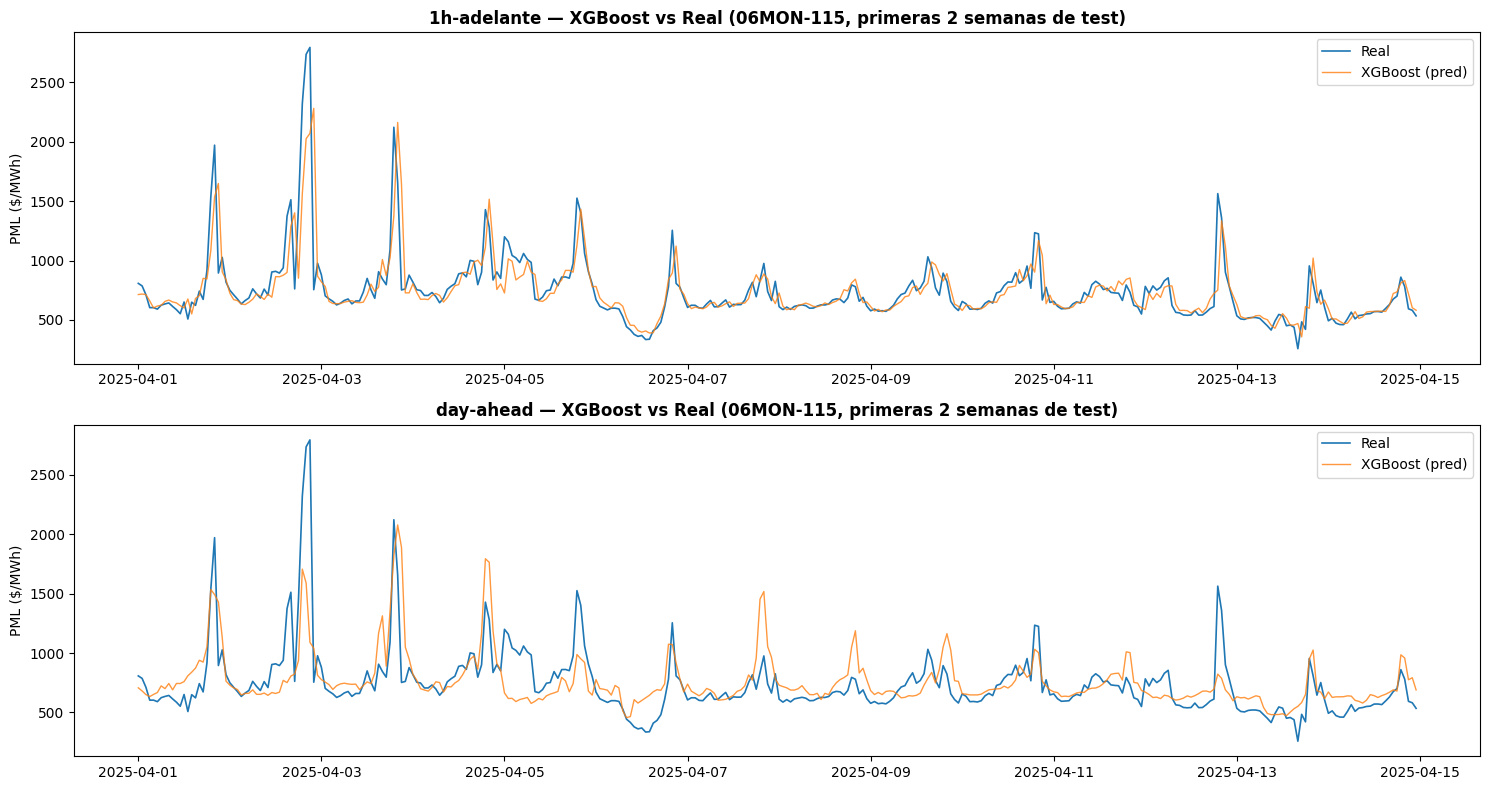

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=False)

# H1: XGBoost (mejor modelo) vs actual, primeros 14 dias del test
n_plot = 24 * 14
axes[0].plot(test_xgb_h1["timestamp"].values[:n_plot], test_xgb_h1["pml"].values[:n_plot], label="Real", lw=1.2)
axes[0].plot(test_xgb_h1["timestamp"].values[:n_plot], preds_xgb_h1[:n_plot], label="XGBoost (pred)", lw=1.0, alpha=0.8)
axes[0].set_title(f"1h-adelante — XGBoost vs Real ({PILOT_NODE}, primeras 2 semanas de test)", fontweight="bold")
axes[0].set_ylabel("PML ($/MWh)")
axes[0].legend()

# day-ahead: XGBoost vs actual, mismo tramo
axes[1].plot(test_xgb_da["timestamp"].values[:n_plot], test_xgb_da["pml"].values[:n_plot], label="Real", lw=1.2)
axes[1].plot(test_xgb_da["timestamp"].values[:n_plot], preds_xgb_da[:n_plot], label="XGBoost (pred)", lw=1.0, alpha=0.8)
axes[1].set_title(f"day-ahead — XGBoost vs Real ({PILOT_NODE}, primeras 2 semanas de test)", fontweight="bold")
axes[1].set_ylabel("PML ($/MWh)")
axes[1].legend()

plt.tight_layout()
plt.show()

#### Figuras para el reporte ejecutivo


In [ ]:
best = (pd.DataFrame(results_summary)
        .sort_values("mae").drop_duplicates(["modelo", "horizonte"]))

fig, ax = plt.subplots(figsize=(11, 5.5))
horizontes = ["1h-adelante", "day-ahead"]
modelos = [m for m in ["XGBoost", "LSTM", "ARIMAX+Fourier"] if m in best["modelo"].values]
modelos += [m for m in best["modelo"].unique() if m.startswith("Naive")]

x = np.arange(len(horizontes))
w = 0.8 / len(modelos)
colores = {"XGBoost": "#c0392b", "LSTM": "#2980b9", "ARIMAX+Fourier": "#27ae60"}

for i, mod in enumerate(modelos):
    vals = [best[(best.modelo == mod) & (best.horizonte == h)]["mae"].pipe(
                lambda s: s.iloc[0] if len(s) else np.nan) for h in horizontes]
    pos = x + i * w
    ax.bar(pos, vals, w, label=mod, color=colores.get(mod, "#7f8c8d"))
    for p, v in zip(pos, vals):
        if not np.isnan(v):
            ax.text(p, v, f"{v:.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x + w * (len(modelos) - 1) / 2)
ax.set_xticklabels(horizontes, fontsize=11)
ax.set_ylabel("MAE ($/MWh)")
ax.set_title(f"Error por modelo y horizonte — {PILOT_NODE}", fontweight="bold", fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "pilot_mae_por_modelo.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, (feats, label, data) in zip(axes, [
        (FEATURES_H1, "1h-adelante", g), (FEATURES_DAYAHEAD, "day-ahead", g)]):
    d = data.dropna(subset=feats + ["pml"])
    train = d[d["split"] == "train"]
    params = (res_xgb_h1 if label == "1h-adelante" else res_xgb_da)
    m = xgb.XGBRegressor(random_state=42, n_jobs=-1).fit(train[feats], train["pml"])
    imp = pd.Series(m.feature_importances_, index=feats).sort_values().tail(12)
    ax.barh(imp.index, imp.values, color="#c0392b")
    ax.set_title(f"Importancia de features — {label}", fontweight="bold")
    ax.set_xlabel("ganancia relativa")
plt.tight_layout()
plt.savefig(FIG_DIR / "pilot_feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()

**XGBoost gana en ambos horizontes**
### Para guardar los hiperparámetros con una nueva aproximación correr la siguiente celda:

In [ ]:
import re
import shutil
import yaml

CONFIG_PATH = REPO / "config" / "config.yaml"

# Interruptor de seguridad. En False solo compara; en True reescribe el archivo.
ACTUALIZAR_CONFIG = False


def leer_params_config(path):
    cfg = yaml.safe_load(open(path))
    return {hz: spec["params"] for hz, spec in cfg["forecasting"]["horizons"].items()}


def escribir_params(path, horizonte, params, dry_run=True):
    """
    Reescribe SOLO las lineas de params del horizonte indicado.

    yaml.dump() no sirve aqui: reserializa todo el documento y borra los
    comentarios, que en este config son la justificacion de cada decision.
    """
    lineas = Path(path).read_text().splitlines(keepends=True)

    i_hz = next(i for i, l in enumerate(lineas)
                if re.match(rf"^\s{{4}}{re.escape(horizonte)}:\s*$", l))
    i_par = next(i for i in range(i_hz, len(lineas))
                 if re.match(r"^\s+params:\s*$", lineas[i]))

    indent = len(lineas[i_par]) - len(lineas[i_par].lstrip())
    hijo = " " * (indent + 2)

    j = i_par + 1
    while j < len(lineas):
        l = lineas[j]
        if l.strip() and (len(l) - len(l.lstrip())) <= indent:
            break
        j += 1

    nuevo = "".join(f"{hijo}{k}: {v}\n" for k, v in params.items())
    if "random_state" not in params:
        nuevo += f"{hijo}random_state: 42\n"

    if not dry_run:
        shutil.copy(path, str(path) + ".bak")
        Path(path).write_text("".join(lineas[:i_par + 1]) + nuevo + "".join(lineas[j:]))
    return nuevo


encontrados = {"h1": best_h1_params, "day_ahead": best_da_params}
en_config = leer_params_config(CONFIG_PATH)

print("COMPARACION notebook <-> config")
print("=" * 70)
hay_diferencias = False
for hz, nuevos in encontrados.items():
    actual = {k: v for k, v in en_config[hz].items() if k != "random_state"}
    difiere = actual != nuevos
    hay_diferencias |= difiere
    print(f"\n{hz}: {'DIFIEREN' if difiere else 'coinciden'}")
    for k in sorted(nuevos):
        marca = "  <-- cambia" if actual.get(k) != nuevos[k] else ""
        print(f"  {k:<20} config={str(actual.get(k)):<8} tuning={str(nuevos[k]):<8}{marca}")

if not hay_diferencias:
    print("\nEl config ya refleja el tuning. No hay nada que actualizar.")
elif ACTUALIZAR_CONFIG:
    for hz, nuevos in encontrados.items():
        escribir_params(CONFIG_PATH, hz, nuevos, dry_run=False)
    print(f"\nCONFIG ACTUALIZADO. Respaldo en {CONFIG_PATH}.bak")
    print("Verificacion:", leer_params_config(CONFIG_PATH))
else:
    print("\nHay diferencias y ACTUALIZAR_CONFIG = False: no se escribio nada.")
    print("Para aplicarlas, poner ACTUALIZAR_CONFIG = True y reejecutar esta celda.")